# AutoGen, end to end: agents, tools, and a local Text2SQL system

A hands-on tutorial in two steps.

**Step 1 — The nitty-gritty.** What an AutoGen agent actually *is*, how two
agents talk, how to make conversations terminate, sequential chats,
reflection, nested reviews, **tools** (function calling), a **code
executor**, and how a group-chat manager routes a team. Every pattern is
ONE small runnable example with a printed *expected output*, so the
notebook stays useful even if you don't have an OpenAI key handy.

**Step 2 — A real local project.** A runnable repository, managed entirely
with **`uv`**, that wires up a small multi-agent system:

- a **Weather agent** calling a live free API,
- a **Text2SQL agent** answering questions over a SQLite database in a
  **ReAct** loop, and
- a **router** that dispatches to the right specialist.

Everything is AutoGen. Step 2 writes an actual project to disk that you
can `uv run`.

### Who this is for & prerequisites

You write Python comfortably and have seen "LLM + tools" before. You do
**not** need prior AutoGen experience. You will need:

- Python ≥ 3.10
- (Optional) `OPENAI_API_KEY` to run examples live — without one, every
  example falls back to its expected output and the notebook still runs.
- [`uv`](https://docs.astral.sh/uv/) for Step 2.

## Environment setup

The PyPI names **`ag2`**, **`autogen`**, and **`pyautogen`** install the
*same* library — AutoGen was renamed AG2 in late 2024 (Apache 2.0 from
v0.3+). The import is still `import autogen`.

> **Which AutoGen?** This notebook teaches the *classic* conversational-
> agent API (`ConversableAgent`, `initiate_chat`, `register_function`) —
> the one the DeepLearning.AI short course uses. Microsoft also publishes
> `autogen-core` / `autogen-agentchat`, an event-driven rewrite with a
> different API surface; that's out of scope here.

In [ ]:
%pip install -q "ag2[openai]" python-dotenv httpx

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 24.4 MB/s eta 0:00:00


In [ ]:
# Option A — install into this notebook's kernel:
# %pip install -q "ag2[openai]" python-dotenv httpx

# Option B — terminal with uv (Part 2's project uses this):
#   uv add "ag2[openai]" python-dotenv httpx

import sys
print("Python:", sys.version.split()[0])
import autogen
print("autogen imported OK — module:", autogen.__name__)

Python: 3.12.13
autogen imported OK — module: autogen


## API key and notebook helpers

If `OPENAI_API_KEY` isn't already in the environment, the cell below
prompts for it (press **Enter to skip** — every example still works,
showing its expected output instead).

Two small helpers — `reply_or_show` and `chat_or_show` — wrap the two
AutoGen entry points we use throughout Part 1:

- with a key, they run live;
- without one, they print a pre-canned *expected* transcript so **Run All**
  stays green.

In [ ]:
import os
from getpass import getpass
os.environ["OPENAI_API_KEY"] = getpass("Open AI API Key")

Open AI API Key··········


In [ ]:
import os, sys
from getpass import getpass

# Interactive Jupyter: prompt. Non-interactive (nbconvert/CI): skip silently.
if not os.environ.get("OPENAI_API_KEY") and sys.stdin.isatty():
    try:
        key = getpass("OPENAI_API_KEY (Enter to skip): ").strip()
        if key:
            os.environ["OPENAI_API_KEY"] = key
    except (EOFError, KeyboardInterrupt):
        pass

HAS_KEY = bool(os.environ.get("OPENAI_API_KEY"))
print("OPENAI_API_KEY detected:", HAS_KEY)


def reply_or_show(agent, content, expected):
    """Run agent.generate_reply([...]) live, or print the expected reply."""
    if HAS_KEY:
        out = agent.generate_reply(
            messages=[{"content": content, "role": "user"}]
        )
        print(out)
        return out
    print("--- no key — showing expected reply ---")
    print(expected)
    return expected


def chat_or_show(sender, recipient, message, expected, **kwargs):
    """Run sender.initiate_chat(recipient, ...) live, or print expected."""
    if HAS_KEY:
        return sender.initiate_chat(recipient, message=message, **kwargs)
    print("--- no key — showing expected transcript ---")
    print(expected)
    return None

OPENAI_API_KEY detected: True


And the shared model configuration. We pass `api_key` explicitly so
the OpenAI client can be *constructed* even with no real key set; every
live call is still gated by `HAS_KEY` above.

In [ ]:
llm_config = {
    "model": "gpt-4o-mini",
    "api_key": os.environ.get("OPENAI_API_KEY", "sk-placeholder"),
}
print("Model:", llm_config["model"])

Model: gpt-4o-mini


# Part 1 — AutoGen, the nitty-gritty

## The mental model

AutoGen frames an application as **conversational agents exchanging
messages**. You rarely write a control-flow loop yourself. Instead you:

1. Create agents, each with a role (`system_message`) and a human-input
   policy (`human_input_mode`).
2. Decide how they are wired — single back-and-forth, a sequence with
   carry-over, a reviewer nested inside another chat, or a managed group.
3. Hand them capabilities: tools (Python functions the LLM can call) and
   a **code executor** (a sandbox that runs code the LLM writes).
4. Kick the whole thing off with one `initiate_chat(...)` call and read
   the structured `chat_result` that comes back.

Each pattern below is just a different way of connecting the same
`ConversableAgent` building block.

![image](https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/198/895/original/img1.png?1779712369)

## A tiny runnable agent

The smallest real thing: **one agent, one prompt, one reply.**
`generate_reply` is AutoGen's lowest-level entry point — one turn, no
partner agent, no memory across calls.

![image](https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/198/898/original/img2.png?1779712505)

In [ ]:
from autogen import ConversableAgent

chatbot = ConversableAgent(
    name="chatbot",
    llm_config=llm_config,
    human_input_mode="NEVER",
)

reply_or_show(
    chatbot,
    "Tell me a one-line joke about databases.",
    expected="Why did the database administrator leave his wife? "
             "She had too many one-to-many relationships.",
)

Why did the database administrator break up with their partner? Too many relational issues!


'Why did the database administrator break up with their partner? Too many relational issues!'

Five constructor arguments carry almost all of `ConversableAgent`'s
behaviour:

- **`name`** — how the agent appears in the transcript.
- **`system_message`** — the role/instructions. Single biggest lever.
- **`llm_config`** — the model dict, or `False` to make the agent *not*
  call an LLM at all (used for pure executors and human proxies).
- **`human_input_mode`** — `"NEVER"`, `"TERMINATE"`, or `"ALWAYS"`.
- **`is_termination_msg`** — a predicate that ends the conversation when
  it returns `True` for an incoming message.

A sixth, `code_execution_config`, appears later when we give an agent a
sandbox.

## Two agents in conversation

`a.initiate_chat(b, message=..., max_turns=...)` starts a dialogue.
AutoGen delivers `a`'s message to `b`, feeds `b`'s reply back to `a`, and
repeats. Each agent retains the running history. `max_turns` bounds the
exchange.

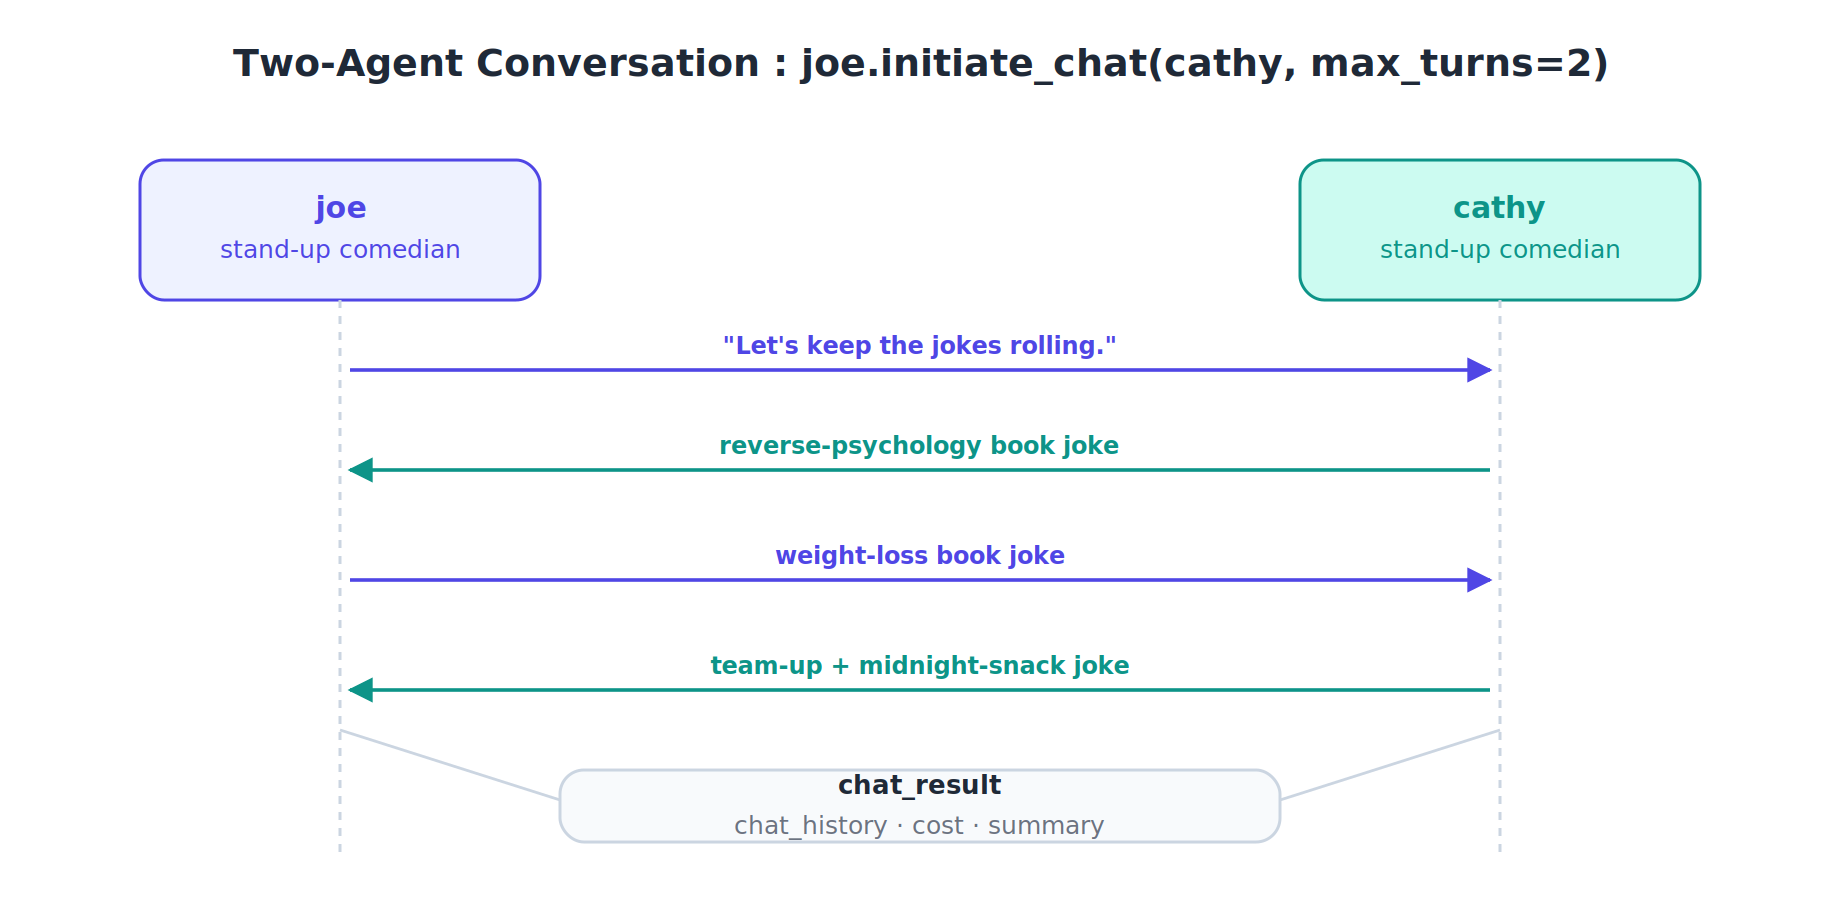

In [ ]:
cathy = ConversableAgent(
    name="cathy",
    system_message="Your name is Cathy and you are a stand-up comedian.",
    llm_config=llm_config,
    human_input_mode="NEVER",
)
joe = ConversableAgent(
    name="joe",
    system_message=(
        "Your name is Joe and you are a stand-up comedian. "
        "Start the next joke from the punchline of the previous joke."
    ),
    llm_config=llm_config, human_input_mode="NEVER",
)

EXPECTED_BANTER = """\
joe (to cathy):
I'm Joe. Cathy, let's keep the jokes rolling.

--------------------------------------------------------------------------------
cathy (to joe):
Sure Joe! Why don't scientists trust atoms?
Because they make up everything!

--------------------------------------------------------------------------------
joe (to cathy):
Speaking of making things up — my therapist says I have a preoccupation
with vengeance. We'll see about that.

--------------------------------------------------------------------------------
cathy (to joe):
"We'll see about that" — that's also what I said before my last show.
The audience said it back, in unison.
"""

chat_result = chat_or_show(
    joe, cathy,
    message="I'm Joe. Cathy, let's keep the jokes rolling.",
    expected=EXPECTED_BANTER,
    max_turns=2,
)

joe (to cathy):

I'm Joe. Cathy, let's keep the jokes rolling.

--------------------------------------------------------------------------------
cathy (to joe):

Absolutely, Joe! Here’s one for you: 

Why don’t scientists trust atoms?

Because they make up everything! 

Now, your turn! Got any good ones up your sleeve?

--------------------------------------------------------------------------------
joe (to cathy):

Speaking of making up everything, did you hear about the mathematician who’s afraid of negative numbers? 

He'll stop at nothing to avoid them!

--------------------------------------------------------------------------------
cathy (to joe):

That’s a good one, Joe! Classic math humor! Here’s another for you: 

I told my therapist about my fear of commitment. 

Now we only meet once a month! 

Keep them coming!

--------------------------------------------------------------------------------

>>>>>>>> TERMINATING RUN (aed21b9d-bb02-40d2-aebf-e5680d251783): Maximum turns (2)

### Reading the AutoGen trace

What you just saw — live or expected — is AutoGen's default verbose
output. The pattern is consistent:

```text
<speaker> (to <recipient>):     <- header: who just produced this message
<body of the message>

--------------------------------------------------------------------------------
<next speaker> (to <new recipient>):
<their reply>
```

The header line is always `<speaker> (to <recipient>):`. The dashed line
is the turn separator. Knowing this is enough to skim any AutoGen log.

When a **tool call** happens (you'll see this in the *Tool use* section
below) you also get the proposal and the result:

```text
assistant (to tool_executor):
***** Suggested tool call (call_xyz): add *****     <- proposes the call
Arguments:
{"a": 2024, "b": 1}                                  <- typed input
***********************************************

>>>>>>>> EXECUTING FUNCTION add...                   <- executor runs it
tool_executor (to assistant):
***** Response from calling tool (call_xyz) *****
2025                                                 <- observation
*************************************************
```

The four moments to look for are **the proposal** (Suggested tool call +
Arguments), **the execution** (`>>>>>>>> EXECUTING`), **the observation**
(Response from calling tool), and **the final answer** in the speaker's
next turn. On a tool error the observation contains the error string and
the caller emits another proposal — that's the AutoGen retry loop.

### What `chat_result` carries

The return value isn't just text. It carries the full history, a
token/cost breakdown, and a summary — so you can consume an agent
conversation programmatically rather than scraping stdout.

In [ ]:
if chat_result is not None:
    print("turns:    ", len(chat_result.chat_history))
    last = chat_result.chat_history[-1].get("content", "")
    print("last msg :", (last[:80] + "…") if len(last) > 80 else last)
    cost = chat_result.cost.get("usage_including_cached_inference", {})
    print("cost (usd):", cost.get("total_cost"))
    print("summary  :", chat_result.summary[:80])
else:
    print("--- no key — example of what chat_result carries ---")
    print("turns:     4")
    print("last msg : 'We'll see about that' — that's also what I said …")
    print("cost (usd): 0.000123")
    print("summary  : 'We'll see about that' — that's also what I said …")

turns:     4
last msg : That’s a good one, Joe! Classic math humor! Here’s another for you: 

I told my …
cost (usd): 0.00010334999999999999
summary  : That’s a good one, Joe! Classic math humor! Here’s another for you: 

I told my 


By default `summary` is just the last message. Ask for an
LLM-written abstractive summary with `summary_method="reflection_with_llm"`
when a downstream step needs the *gist*, not the transcript.

## Making conversations stop

Two independent stop conditions:

- **`max_turns`** on `initiate_chat` — a hard cap.
- **`is_termination_msg`** — a predicate over each incoming message that
  ends the conversation when it returns `True`. This lets an agent decide
  *semantically* that it is done.

Without either, two LLM agents will talk until they hit a length limit.
Real systems almost always use `is_termination_msg`.

In [ ]:
cathy_t = ConversableAgent(
    name="cathy",
    system_message=(
        "You are Cathy, a stand-up comedian. Tell ONE short joke, then "
        "end your reply with the exact phrase 'I gotta go'."
    ),
    llm_config=llm_config, human_input_mode="NEVER",
    is_termination_msg=lambda m: "I gotta go" in (m.get("content") or ""),
)
joe_t = ConversableAgent(
    name="joe",
    system_message="You are Joe, a stand-up comedian. Be brief.",
    llm_config=llm_config, human_input_mode="NEVER",
    is_termination_msg=lambda m: "I gotta go" in (m.get("content") or ""),
)

EXPECTED_TERM = """\
joe (to cathy):
Hey Cathy, quick joke?

--------------------------------------------------------------------------------
cathy (to joe):
Why do programmers prefer dark mode? Because light attracts bugs.
I gotta go.

>>>>>>>> TERMINATING RUN (joe): Termination message condition on agent
'joe' met
"""

chat_or_show(joe_t, cathy_t,
             message="Hey Cathy, quick joke?",
             expected=EXPECTED_TERM)

joe (to cathy):

Hey Cathy, quick joke?

--------------------------------------------------------------------------------
cathy (to joe):

Why don't scientists trust atoms? Because they make up everything! I gotta go.

--------------------------------------------------------------------------------

>>>>>>>> TERMINATING RUN (ce000a63-7c0f-4bc2-9568-095fc9946388): Termination message condition on agent 'joe' met


ChatResult(chat_id=27820915910532177664718076233696594302, chat_history=[{'content': 'Hey Cathy, quick joke?', 'role': 'assistant', 'name': 'joe'}, {'content': "Why don't scientists trust atoms? Because they make up everything! I gotta go.", 'role': 'user', 'name': 'cathy'}], summary="Why don't scientists trust atoms? Because they make up everything! I gotta go.", cost={'usage_including_cached_inference': {'total_cost': 1.6499999999999998e-05, 'gpt-4o-mini-2024-07-18': {'cost': 1.6499999999999998e-05, 'prompt_tokens': 46, 'completion_tokens': 16, 'total_tokens': 62}}, 'usage_excluding_cached_inference': {'total_cost': 1.6499999999999998e-05, 'gpt-4o-mini-2024-07-18': {'cost': 1.6499999999999998e-05, 'prompt_tokens': 46, 'completion_tokens': 16, 'total_tokens': 62}}}, human_input=[])

## Sequential chats with carry-over

`initiate_chats([...])` runs a **list** of chats in order and threads a
*summary* of each finished chat into the next as context ("carry-over").
A pipeline of focused chats beats one sprawling prompt.

The example below chains three small steps: pick a topic → write a haiku
about it → translate the haiku to one English sentence. Each step is
`max_turns=1` and `summary_method="last_msg"`, so each step's last
message becomes the next step's context.

![image](https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/198/899/original/img3.png?1779712542)

In [ ]:
from autogen import initiate_chats

step1 = ConversableAgent(
    name="step1",
    system_message="Pick a one-word topic for a haiku. Output only that word.",
    llm_config=llm_config, human_input_mode="NEVER",
)
step2 = ConversableAgent(
    name="step2",
    system_message=(
        "Write a haiku about the topic provided in the conversation. "
        "Output only the haiku (3 lines)."
    ),
    llm_config=llm_config, human_input_mode="NEVER",
)
step3 = ConversableAgent(
    name="step3",
    system_message=(
        "Translate the haiku in the conversation into ONE short English "
        "sentence. Output only that sentence."
    ),
    llm_config=llm_config, human_input_mode="NEVER",
)
nudge = ConversableAgent(
    name="nudge", llm_config=False, human_input_mode="NEVER",
    default_auto_reply="OK",
)

chats = [
    {"sender": nudge, "recipient": step1, "message": "Give me a topic.",
     "summary_method": "last_msg", "max_turns": 1, "clear_history": True},
    {"sender": nudge, "recipient": step2,
     "message": "Use the topic from the previous step.",
     "summary_method": "last_msg", "max_turns": 1, "clear_history": False},
    {"sender": nudge, "recipient": step3,
     "message": "Translate the haiku from the previous step.",
     "summary_method": "last_msg", "max_turns": 1, "clear_history": False},
]

EXPECTED_SEQ = """\
--- step 1 summary ---
Autumn.

--- step 2 summary ---
Crisp leaves let go now —
the maple breathes one last sigh,
red light on the floor.

--- step 3 summary ---
Autumn leaves quietly fall as the maple tree exhales its last red light.
"""

if HAS_KEY:
    results = initiate_chats(chats)
    for i, r in enumerate(results, 1):
        print(f"--- step {i} summary ---")
        print(r.summary, "\n")
else:
    print("--- no key — showing expected per-step summaries ---")
    print(EXPECTED_SEQ)


********************************************************************************
Starting a new chat....

********************************************************************************
nudge (to step1):

Give me a topic.

--------------------------------------------------------------------------------
step1 (to nudge):

Whisper

--------------------------------------------------------------------------------

>>>>>>>> TERMINATING RUN (c8990935-6e0d-4c71-bbdf-65b6d8ff6c2a): Maximum turns (1) reached

********************************************************************************
Starting a new chat....

********************************************************************************
nudge (to step2):

Use the topic from the previous step.
Context: 
Whisper

--------------------------------------------------------------------------------
step2 (to nudge):

Gentle breeze that speaks,  
Secrets carried on soft sighs,  
Nature's tender nudge.

-------------------------------------------

## Reflection: a writer and a critic

Reflection = pair a *producer* with a *reviewer* and let the producer
revise. The L3 pattern: a `Writer` drafts, a `Critic` initiates a chat
with it, critiques, and the writer returns a refined version. With
`max_turns=2` you get exactly one draft → one critique → one revision.

![image](https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/198/900/original/img4.png?1779712570)

In [ ]:
import autogen

writer = autogen.AssistantAgent(
    name="Writer", llm_config=llm_config,
    system_message=(
        "You write tight 3-line poems. Revise based on feedback. "
        "Return only the final poem, no commentary."
    ),
)
critic = autogen.AssistantAgent(
    name="Critic", llm_config=llm_config,
    is_termination_msg=lambda x: "TERMINATE" in (x.get("content") or ""),
    system_message=(
        "You critique poems. Give ONE concrete suggestion to improve the "
        "poem, then say 'Now revise.'"
    ),
)

EXPECTED_REFL = """\
Critic (to Writer):
Write a 3-line poem about ML reproducibility.

--------------------------------------------------------------------------------
Writer (to Critic):
A seed planted twice
grows two different gardens —
fix the random state.

--------------------------------------------------------------------------------
Critic (to Writer):
The image 'two different gardens' is good but soft. Try a sharper risk
word that signals failure, not just variation. Now revise.

--------------------------------------------------------------------------------
Writer (to Critic):
A seed planted twice
grows two unmatched gardens —
pin your random state.
"""
#sender.initiate_chat(recipient,message)
#critic.initiate_chat(writer)
chat_or_show(
    critic, writer,
    message="Write a 3-line poem about ML reproducibility.",
    expected=EXPECTED_REFL,
    max_turns=2, summary_method="last_msg",
)

Critic (to Writer):

Write a 3-line poem about ML reproducibility.

--------------------------------------------------------------------------------
Writer (to Critic):

Data sets and models play,  
Silent echoes of lost decay,  
Truth fades in the fray.

--------------------------------------------------------------------------------
Critic (to Writer):

This poem presents a compelling theme, but it could benefit from stronger imagery or a more concrete example to illustrate the concept of ML reproducibility. Perhaps consider incorporating a metaphor or a specific image related to data or algorithms that enhances the emotional impact. 

Now revise.

--------------------------------------------------------------------------------
Writer (to Critic):

In code's labyrinth, echoes stray,  
Fragile models drift like clay,  
Truth morphs, then slips away.

--------------------------------------------------------------------------------

>>>>>>>> TERMINATING RUN (dfd207f1-d0fa-4fe3-827e-7f98

ChatResult(chat_id=217750824480910405809952821786708019465, chat_history=[{'content': 'Write a 3-line poem about ML reproducibility.', 'role': 'assistant', 'name': 'Critic'}, {'content': 'Data sets and models play,  \nSilent echoes of lost decay,  \nTruth fades in the fray.', 'role': 'user', 'name': 'Writer'}, {'content': 'This poem presents a compelling theme, but it could benefit from stronger imagery or a more concrete example to illustrate the concept of ML reproducibility. Perhaps consider incorporating a metaphor or a specific image related to data or algorithms that enhances the emotional impact. \n\nNow revise.', 'role': 'assistant', 'name': 'Critic'}, {'content': "In code's labyrinth, echoes stray,  \nFragile models drift like clay,  \nTruth morphs, then slips away.", 'role': 'user', 'name': 'Writer'}], summary="In code's labyrinth, echoes stray,  \nFragile models drift like clay,  \nTruth morphs, then slips away.", cost={'usage_including_cached_inference': {'total_cost': 9.67

## Nested chats: a review panel behind one reviewer

Reflection scales by **nesting**. `critic.register_nested_chats(queue,
trigger=writer)` says: *whenever a message from `writer` reaches
`critic`, first run this private queue of sub-chats, then let `critic`
answer using their results.*

A minimal version with two reviewers and an aggregator (the full L3
pattern adds Legal and Ethics reviewers in the same shape).

![image](https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/198/901/original/img5.png?1779712597)

In [ ]:
clarity_reviewer = autogen.AssistantAgent(
    name="Clarity_Reviewer", llm_config=llm_config,
    system_message=(
        "You review prose for clarity. Give ONE concise suggestion. "
        "Begin by stating your role."
    ),
)
tone_reviewer = autogen.AssistantAgent(
    name="Tone_Reviewer", llm_config=llm_config,
    system_message=(
        "You review prose for tone. Give ONE concise suggestion. "
        "Begin by stating your role."
    ),
)
meta = autogen.AssistantAgent(
    name="Meta_Reviewer", llm_config=llm_config,
    system_message=(
        "You aggregate reviewer feedback into one final recommendation."
    ),
)

def make_review_msg(recipient, messages, sender, config):
    last = recipient.chat_messages_for_summary(sender)[-1]["content"]
    return f"Review this:\n\n{last}"

review_queue = [
    {"recipient": clarity_reviewer, "message": make_review_msg,
     "max_turns": 1, "summary_method": "last_msg"},
    {"recipient": tone_reviewer, "message": make_review_msg,
     "max_turns": 1, "summary_method": "last_msg"},
    {"recipient": meta,
     "message": "Aggregate the reviewers' suggestions into one final note.",
     "max_turns": 1, "summary_method": "last_msg"},
]

critic.register_nested_chats(review_queue, trigger=writer)

EXPECTED_NESTED = """\
Critic (to Writer):
Write a 3-line poem about ML reproducibility.

--------------------------------------------------------------------------------
Writer (to Critic):
A seed planted twice grows two different gardens — fix the random state.

[nested review panel runs silently inside Critic]
  Clarity_Reviewer  -> 'different' is vague; try 'unmatched' for sharper risk.
  Tone_Reviewer     -> Read as 3 lines, not one; preserve the haiku break.
  Meta_Reviewer     -> Use 'unmatched', restore the 3-line break.

--------------------------------------------------------------------------------
Critic (to Writer):
Two notes from the panel: sharpen 'different' and restore the 3-line break.
Now revise.

--------------------------------------------------------------------------------
Writer (to Critic):
A seed planted twice
grows two unmatched gardens —
pin your random state.
"""

chat_or_show(
    critic, writer,
    message="Write a 3-line poem about ML reproducibility.",
    expected=EXPECTED_NESTED,
    max_turns=2, summary_method="last_msg",
)

Critic (to Writer):

Write a 3-line poem about ML reproducibility.

--------------------------------------------------------------------------------
Writer (to Critic):

In code's embrace, we strive for truth,  
Yet datasets shift like shadows in flight,  
A fragile promise, lost in the night.

--------------------------------------------------------------------------------

********************************************************************************
Starting a new chat....

********************************************************************************
Critic (to Clarity_Reviewer):

Review this:

In code's embrace, we strive for truth,  
Yet datasets shift like shadows in flight,  
A fragile promise, lost in the night.

--------------------------------------------------------------------------------
Clarity_Reviewer (to Critic):

As a critic, I suggest clarifying the metaphor in the first line. Consider rephrasing "In code's embrace" to make the connection between code and truth 

ChatResult(chat_id=177948494759256809866131156062532789941, chat_history=[{'content': 'Write a 3-line poem about ML reproducibility.', 'role': 'assistant', 'name': 'Critic'}, {'content': "In code's embrace, we strive for truth,  \nYet datasets shift like shadows in flight,  \nA fragile promise, lost in the night.", 'role': 'user', 'name': 'Writer'}, {'content': 'Final Recommendation:\n\nTo improve the overall clarity and impact of your work, it is advisable to clarify the metaphor in the opening line. Specifically, rephrase "In code\'s embrace" to more explicitly connect code with the theme of truth. Consider detailing how code fosters or reveals truth to enhance the imagery and strengthen the reader\'s understanding of this relationship.', 'role': 'assistant', 'name': 'Critic'}, {'content': 'In lines of code, we seek the truth,  \nYet datasets shift like shadows in flight,  \nA fragile promise, lost in the night.', 'role': 'user', 'name': 'Writer'}], summary='In lines of code, we seek

## Tool use (function calling)

A **tool** is a normal Python function the model may decide to call.
AutoGen splits the responsibility across two agents:

- the **caller** — its LLM sees the tool's schema and may *propose* a call;
- the **executor** — actually *runs* the function and returns the result.

We'll do this in two steps, in the order a working engineer would:
**first define the tool and call it directly** (no LLM, no key, just a
typed Python function), **then** hand it to an agent.

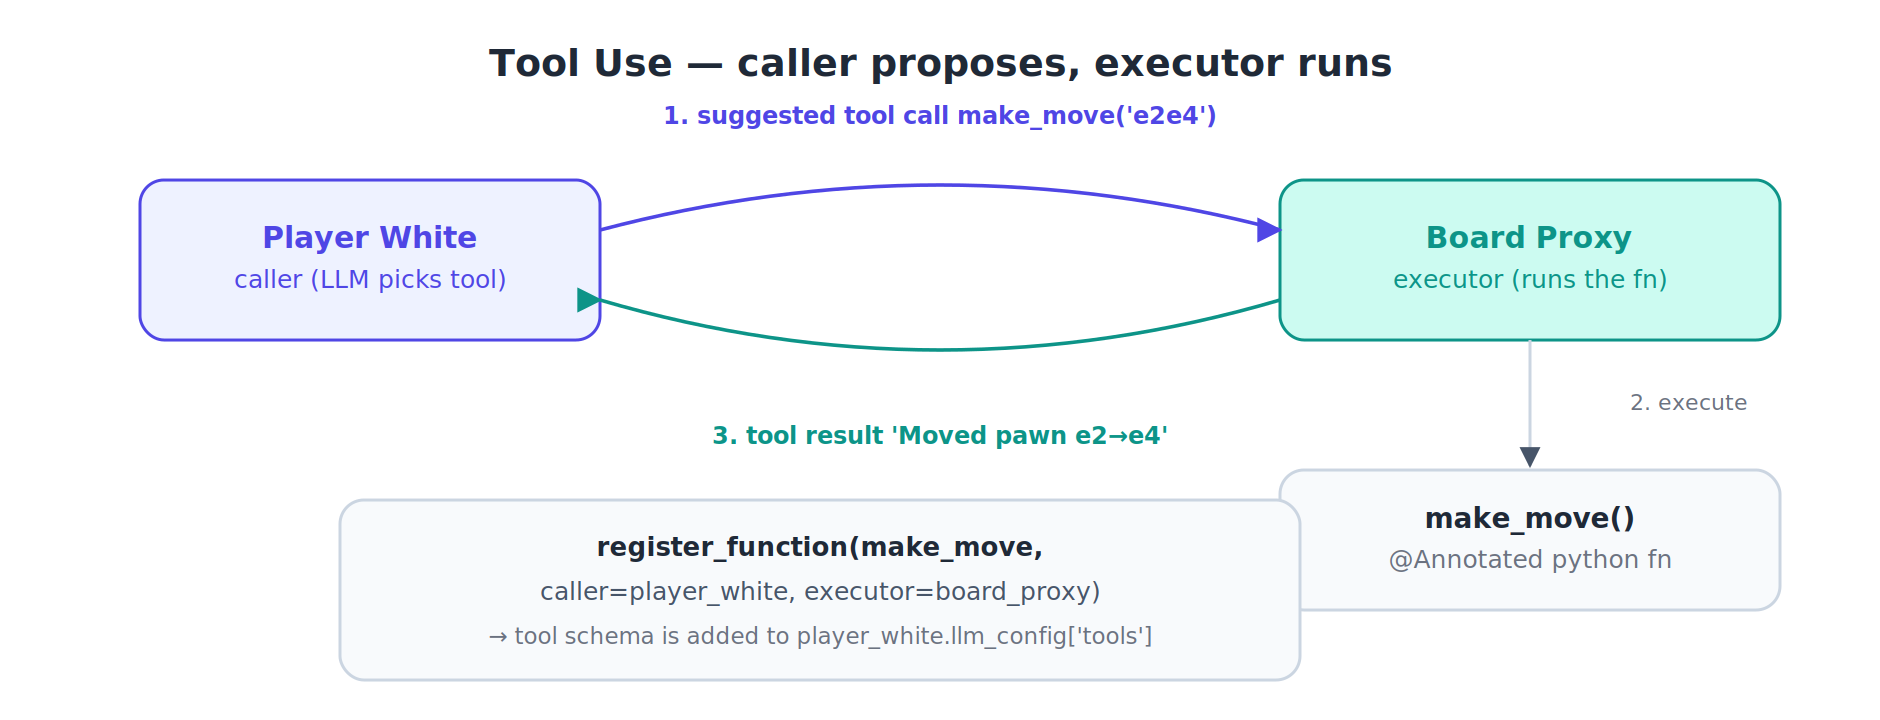

### Step 1 — define the tool, call it directly

A tool is just a typed function. `Annotated[type, "description"]` turns
the type hint into the JSON schema the model will see. Test it without
any LLM first.

In [ ]:
from typing import Annotated

def add(
    a: Annotated[int, "first integer"],
    b: Annotated[int, "second integer"],
) -> Annotated[int, "the sum a + b"]:
    """Add two integers."""
    return a + b

# RUNS with no LLM / no key — a tool is just a typed function:
print(add(2024, 1))   # -> 2025
print(add(-3, 3))     # -> 0

2025
0


### Step 2 — register it and let an agent call it

`register_function(fn, caller=..., executor=..., name=..., description=...)`
wires one function to a caller/executor pair. The caller proposes; the
executor runs and returns the result.

In [ ]:
from autogen import register_function

assistant = ConversableAgent(
    name="assistant",
    system_message=(
        "Use the `add` tool for any addition. When the task is done, "
        "reply with the single word TERMINATE."
    ),
    llm_config=llm_config, human_input_mode="NEVER",
)
tool_executor = ConversableAgent(
    name="tool_executor", llm_config=False,
    human_input_mode="NEVER",
    is_termination_msg=lambda m: m.get("content") is not None
    and "TERMINATE" in m["content"],
)

register_function(
    add, caller=assistant, executor=tool_executor,
    name="add", description="Add two integers and return their sum.",
)

# Schema the model actually sees — derived from the type hints:
import json
print(json.dumps(assistant.llm_config["tools"], indent=2))

[
  {
    "type": "function",
    "function": {
      "description": "Add two integers and return their sum.",
      "name": "add",
      "parameters": {
        "type": "object",
        "properties": {
          "a": {
            "type": "integer",
            "description": "first integer"
          },
          "b": {
            "type": "integer",
            "description": "second integer"
          }
        },
        "required": [
          "a",
          "b"
        ]
      }
    }
  }
]


In [ ]:
EXPECTED_TOOL = """\
tool_executor (to assistant):
What is 2024 + 1 ? Use the tool, then report the answer.

--------------------------------------------------------------------------------
assistant (to tool_executor):
***** Suggested tool call (call_xyz): add *****
Arguments:
{"a": 2024, "b": 1}
***********************************************

>>>>>>>> EXECUTING FUNCTION add...
tool_executor (to assistant):
***** Response from calling tool (call_xyz) *****
2025
*************************************************

--------------------------------------------------------------------------------
assistant (to tool_executor):
The answer is 2025. TERMINATE
"""

chat_or_show(
    tool_executor, assistant,
    message="What is 2024 + 1 ? Use the tool, then report the answer.",
    expected=EXPECTED_TOOL,
)

tool_executor (to assistant):

What is 2024 + 1 ? Use the tool, then report the answer.

--------------------------------------------------------------------------------
assistant (to tool_executor):

***** Suggested tool call (call_woR3zEYylomSkG2S0MX4OVld): add *****
Arguments: 
{"a":2024,"b":1}
********************************************************************

--------------------------------------------------------------------------------

>>>>>>>> EXECUTING FUNCTION add...
Call ID: call_woR3zEYylomSkG2S0MX4OVld
Input arguments: {'a': 2024, 'b': 1}

>>>>>>>> EXECUTED FUNCTION add...
Call ID: call_woR3zEYylomSkG2S0MX4OVld
Input arguments: {'a': 2024, 'b': 1}
Output:
2025
tool_executor (to assistant):

***** Response from calling tool (call_woR3zEYylomSkG2S0MX4OVld) *****
2025
**********************************************************************

--------------------------------------------------------------------------------
assistant (to tool_executor):

2025

-----------------

ChatResult(chat_id=309118988128422132030193694848357493824, chat_history=[{'content': 'What is 2024 + 1 ? Use the tool, then report the answer.', 'role': 'assistant', 'name': 'tool_executor'}, {'tool_calls': [{'id': 'call_woR3zEYylomSkG2S0MX4OVld', 'function': {'arguments': '{"a":2024,"b":1}', 'name': 'add'}, 'type': 'function'}], 'content': None, 'role': 'assistant'}, {'content': '2025', 'tool_responses': [{'tool_call_id': 'call_woR3zEYylomSkG2S0MX4OVld', 'role': 'tool', 'content': '2025'}], 'role': 'tool', 'name': 'tool_executor'}, {'content': '2025', 'role': 'user', 'name': 'assistant'}, {'content': '', 'role': 'assistant', 'name': 'tool_executor'}, {'content': 'TERMINATE', 'role': 'user', 'name': 'assistant'}], summary='', cost={'usage_including_cached_inference': {'total_cost': 7.035e-05, 'gpt-4o-mini-2024-07-18': {'cost': 7.035e-05, 'prompt_tokens': 369, 'completion_tokens': 25, 'total_tokens': 394}}, 'usage_excluding_cached_inference': {'total_cost': 7.035e-05, 'gpt-4o-mini-2024

The same `register_function` pattern powers the **Text2SQL agent**
in Part 2: `list_tables`, `get_schema`, and `run_sql` are just
user-defined functions registered to a caller/executor pair.

## Code execution

Tools are functions *you* wrote. A **code executor** runs code the
*model* writes — useful when you can't enumerate the helpers in advance.
Two agents:

- `code_writer` (`AssistantAgent`, LLM on) emits fenced code blocks;
- `code_executor` (`ConversableAgent`, `llm_config=False`,
  `code_execution_config={"executor": ...}`) runs them in a sandbox and
  feeds stdout/stderr back so the writer can fix errors.

![image](https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/198/902/original/img6.png?1779712631)

> ### ⚠️ Safety — read before running the next cell
>
> `LocalCommandLineCodeExecutor` executes model-generated shell and
> Python commands on the machine running this notebook. There is **no
> sandbox by default**. If the writer hallucinates `rm -rf …` or a
> network call against your filesystem, that runs.
>
> Use it only:
>
> - against a **disposable working directory** (never `$HOME` or a repo dir);
> - with a **short `timeout`** — `30` below is already long for a demo;
> - **never with untrusted prompts**, secrets in env, or production files;
> - **prefer `use_docker=True`** if Docker is available locally.
>
> If you are unsure, skip this cell — every other Part 1 pattern works
> without it.

In [ ]:
from autogen.coding import LocalCommandLineCodeExecutor

local_exec = LocalCommandLineCodeExecutor(timeout=30, work_dir="coding")

code_writer = autogen.AssistantAgent(
    name="code_writer", llm_config=llm_config,
    code_execution_config=False, human_input_mode="NEVER",
)
code_executor_agent = ConversableAgent(
    name="code_executor", llm_config=False,
    code_execution_config={"executor": local_exec},
    human_input_mode="NEVER",
    default_auto_reply="Continue. If done, reply TERMINATE.",
    is_termination_msg=lambda m: m.get("content") is not None
    and "TERMINATE" in m["content"],
)

EXPECTED_EXEC = """\
code_executor (to code_writer):
Compute the first 5 Fibonacci numbers and print them as a Python list. ...

--------------------------------------------------------------------------------
code_writer (to code_executor):
```python
fibs = [0, 1]
while len(fibs) < 5:
    fibs.append(fibs[-1] + fibs[-2])
print(fibs[:5])
```

--------------------------------------------------------------------------------
>>>>>>>> EXECUTING CODE BLOCK (inferred language is python)...
code_executor (to code_writer):
exitcode: 0 (execution succeeded)
Code output: [0, 1, 1, 2, 3]

--------------------------------------------------------------------------------
code_writer (to code_executor):
The first 5 Fibonacci numbers are [0, 1, 1, 2, 3]. TERMINATE
"""

chat_or_show(
    code_executor_agent, code_writer,
    message=(
        "Compute the first 5 Fibonacci numbers and print them as a Python "
        "list. Put the code in a python block. Reply TERMINATE when the "
        "output is shown."
    ),
    expected=EXPECTED_EXEC,
)

code_executor (to code_writer):

Compute the first 5 Fibonacci numbers and print them as a Python list. Put the code in a python block. Reply TERMINATE when the output is shown.

--------------------------------------------------------------------------------
code_writer (to code_executor):

```python
# filename: fibonacci.py
fibonacci_numbers = []
a, b = 0, 1

for _ in range(5):
    fibonacci_numbers.append(a)
    a, b = b, a + b

print(fibonacci_numbers)
```
TERMINATE

--------------------------------------------------------------------------------

>>>>>>>> TERMINATING RUN (108b5ef8-eacd-4b87-ae6b-6a4b81081111): Termination message condition on agent 'code_executor' met


ChatResult(chat_id=228908835944559543180013530651950269515, chat_history=[{'content': 'Compute the first 5 Fibonacci numbers and print them as a Python list. Put the code in a python block. Reply TERMINATE when the output is shown.', 'role': 'assistant', 'name': 'code_executor'}, {'content': '```python\n# filename: fibonacci.py\nfibonacci_numbers = []\na, b = 0, 1\n\nfor _ in range(5):\n    fibonacci_numbers.append(a)\n    a, b = b, a + b\n\nprint(fibonacci_numbers)\n```\nTERMINATE', 'role': 'user', 'name': 'code_writer'}], summary='```python\n# filename: fibonacci.py\nfibonacci_numbers = []\na, b = 0, 1\n\nfor _ in range(5):\n    fibonacci_numbers.append(a)\n    a, b = b, a + b\n\nprint(fibonacci_numbers)\n```\n', cost={'usage_including_cached_inference': {'total_cost': 0.00010965, 'gpt-4o-mini-2024-07-18': {'cost': 0.00010965, 'prompt_tokens': 499, 'completion_tokens': 58, 'total_tokens': 557}}, 'usage_excluding_cached_inference': {'total_cost': 0.00010965, 'gpt-4o-mini-2024-07-18': 

## Group chat and planning

For more than two agents a `GroupChat` holds the roster and shared
message list; a `GroupChatManager` picks who speaks next each round.
Constrain the routing with `allowed_or_disallowed_speaker_transitions`
and `speaker_transitions_type="allowed"` so each agent can only hand off
to the right next role.

A minimal team: **Admin → Planner → Worker → Writer → Admin**.

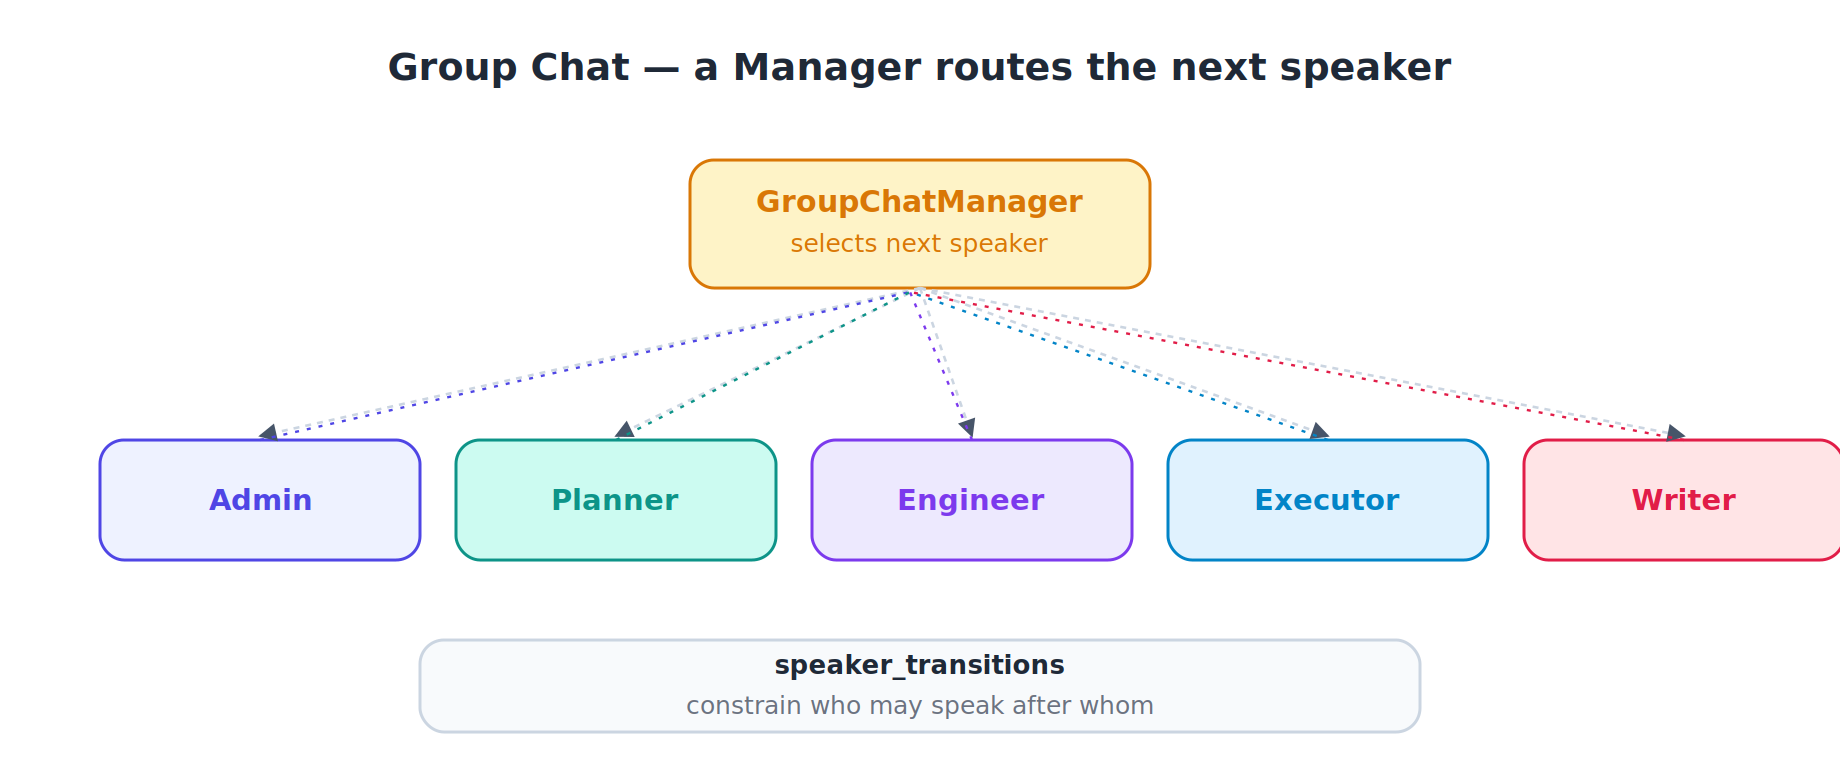

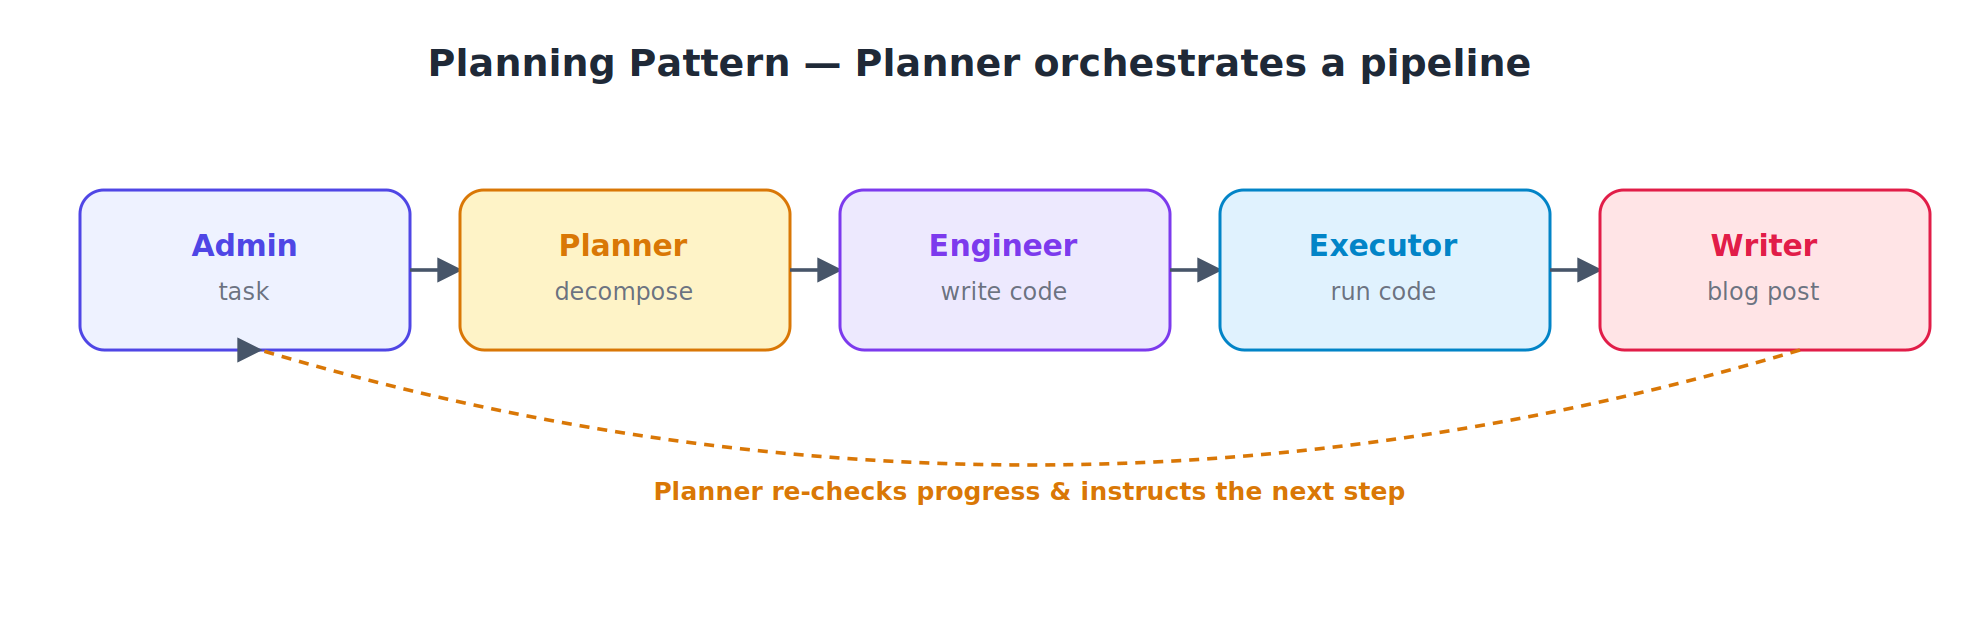

In [ ]:
planner = autogen.AssistantAgent(
    name="Planner", llm_config=llm_config,
    system_message=(
        "Break the request into 1-3 numbered steps. Output only the plan."
    ),
)
worker = autogen.AssistantAgent(
    name="Worker", llm_config=llm_config,
    system_message=(
        "Carry out the plan in your head (no code) and report your findings "
        "concisely. Do not write the final answer."
    ),
)
writer_g = autogen.AssistantAgent(
    name="Writer", llm_config=llm_config,
    system_message=(
        "Using the Worker's findings, write the final 2-sentence answer in "
        "plain English. End your reply with the word TERMINATE."
    ),
)
admin = autogen.ConversableAgent(
    name="Admin", llm_config=False, human_input_mode="NEVER",
    is_termination_msg=lambda m: m.get("content") is not None
    and "TERMINATE" in m["content"],
    default_auto_reply="",
)

groupchat = autogen.GroupChat(
    agents=[admin, planner, worker, writer_g],
    messages=[], max_round=8,
    allowed_or_disallowed_speaker_transitions={
        admin:    [planner],
        planner:  [worker],
        worker:   [writer_g],
        writer_g: [admin],
    },
    speaker_transitions_type="allowed",
)
manager = autogen.GroupChatManager(groupchat=groupchat, llm_config=llm_config)

EXPECTED_GROUP = """\
Admin (to chat_manager):
Explain in 2 sentences why fixed random seeds matter in ML.

Next speaker: Planner
--------------------------------------------------------------------------------
Planner (to chat_manager):
1. Define what a random seed does.
2. Explain why fixing it gives reproducibility.

Next speaker: Worker
--------------------------------------------------------------------------------
Worker (to chat_manager):
A seed initialises the pseudo-random generator. Fixing it makes sampling,
weight init and data shuffling deterministic across runs.

Next speaker: Writer
--------------------------------------------------------------------------------
Writer (to chat_manager):
Random seeds initialise the pseudo-random generator that drives sampling,
weight initialisation, and data shuffling in training. Fixing the seed
makes a run exactly reproducible — same code, data, and seed yield the
same model. TERMINATE
"""

chat_or_show(
    admin, manager,
    message="Explain in 2 sentences why fixed random seeds matter in ML.",
    expected=EXPECTED_GROUP,
)

Admin (to chat_manager):

Explain in 2 sentences why fixed random seeds matter in ML.

--------------------------------------------------------------------------------

Next speaker: Planner

Planner (to chat_manager):

1. Fixed random seeds ensure that experiments in machine learning are reproducible by providing a consistent starting point for randomness, allowing researchers to obtain the same results across multiple runs.  
2. This consistency is crucial for debugging, comparing different models, and validating research findings, as it removes variability introduced by random processes like weight initialization and data shuffling.

--------------------------------------------------------------------------------

Next speaker: Worker

Worker (to chat_manager):

Fixed random seeds are essential in machine learning as they facilitate reproducibility by providing a stable, consistent environment for experiments, enabling researchers to achieve the same outcomes in repeated trials. Thi

ChatResult(chat_id=280406106879583090708515956943852542671, chat_history=[{'content': 'Explain in 2 sentences why fixed random seeds matter in ML.', 'role': 'assistant', 'name': 'Admin'}, {'content': '1. Fixed random seeds ensure that experiments in machine learning are reproducible by providing a consistent starting point for randomness, allowing researchers to obtain the same results across multiple runs.  \n2. This consistency is crucial for debugging, comparing different models, and validating research findings, as it removes variability introduced by random processes like weight initialization and data shuffling.', 'name': 'Planner', 'role': 'user'}, {'content': 'Fixed random seeds are essential in machine learning as they facilitate reproducibility by providing a stable, consistent environment for experiments, enabling researchers to achieve the same outcomes in repeated trials. This reliability is key for effective debugging, model comparison, and validation of research results,

## Quick check

Test the Part 1 mental model. Answers are hidden — think first.

**Q1.** You want an agent that *runs* tools but never calls an LLM
itself. Which `llm_config` value do you give it?

<details><summary>Show answer</summary>

`llm_config=False`. An executor / human-proxy agent should not think
with a model; it only runs functions or relays human input.
</details>

**Q2.** Two LLM agents keep talking forever. You did not set `max_turns`.
What is the idiomatic fix?

<details><summary>Show answer</summary>

Give at least one agent an `is_termination_msg` predicate (e.g. returns
`True` when the message contains `"TERMINATE"` or `"I gotta go"`), and
instruct that agent in its `system_message` to emit that phrase when
finished. `max_turns` is the blunt backup.
</details>

**Q3.** In `register_function`, what is the difference between `caller`
and `executor`?

<details><summary>Show answer</summary>

The **caller**'s LLM sees the tool schema and may *propose* a call; the
**executor** actually *runs* the Python function and returns the result.
They are usually two different agents.
</details>

**Q4.** What does `register_nested_chats(queue, trigger=writer)` do?

<details><summary>Show answer</summary>

When a message from `writer` reaches the agent it was registered on,
AutoGen first runs the entire `queue` of sub-chats privately, then lets
that agent respond using their summarised results — a review panel
hidden behind one agent.
</details>

**Q5.** Which object decides who speaks next in a `GroupChat`, and how
do you restrict the hand-offs?

<details><summary>Show answer</summary>

The `GroupChatManager`. Restrict routing with
`allowed_or_disallowed_speaker_transitions={...}` and
`speaker_transitions_type="allowed"` (or `"disallowed"`).
</details>

## Patterns at a glance

| Pattern | API surface | When to reach for it | Watch out for |
|---|---|---|---|
| Single reply | `agent.generate_reply(messages=...)` | One-shot prompt, no dialogue | Stateless — you carry the history |
| Two-agent chat | `a.initiate_chat(b, message=..., max_turns=...)` | Bounded back-and-forth | Need `max_turns` *or* `is_termination_msg` |
| Sequential chats | `initiate_chats([...])` | Multi-stage pipeline with carry-over | Summary quality propagates downstream |
| Reflection | Writer + Critic; `critic.initiate_chat(writer)` | Single round of self-revision | More tokens; critic can become vague |
| Nested chats | `register_nested_chats(queue, trigger=...)` | Hidden review panel behind one agent | Harder to debug; nested costs add up |
| Tool use | `register_function(fn, caller=, executor=)` | Controlled function calls with a schema | Type hints become the contract |
| Code execution | `LocalCommandLineCodeExecutor` | Open-ended analysis the model writes itself | Sandbox / Docker; never on home dir |
| Group chat | `GroupChat` + `GroupChatManager` | 3+ roles with a routing policy | Constrain speaker transitions explicitly |

Everything in Part 2 is a **combination** of *Tool use* and a small
custom router — no group chat, no code execution. Same primitives,
different wiring.

# From notebook patterns to a real project

Part 1 isolated each pattern. Part 2 packages the same ideas into files
because real agent systems need:

- **reusable modules** instead of one giant notebook,
- **configuration isolated from logic** (`.env` and `config.py`),
- **tools that can be tested without invoking an LLM**,
- **a CLI entrypoint** so the system can run from a script or cron,
- **reproducible dependencies** (`pyproject.toml` + `uv.lock`).

We use **`uv`** rather than `pip` to make the last point real: `uv add`
edits both `pyproject.toml` *and* the lockfile, so a teammate who runs
`uv sync` gets byte-for-byte the same environment.

The cells below use `%%writefile` to materialise the entire project
right next to this notebook. After running them you'll have a real
`autogen-text2sql/` directory you can launch from a terminal with
`uv run python -m src.app`.

# Part 2 — A local repo: multi-agent Text2SQL with `uv`

### What we are building

Two specialists behind a router:

- **Weather agent** — given a city, it calls a **live, free weather API**
  (Open-Meteo, no key needed) through an AutoGen-registered tool and
  reports the current conditions.
- **Text2SQL agent** — given a question about the data, it inspects a
  local SQLite database and answers it by writing and running SQL, using
  **user-defined tools** (`list_tables`, `get_schema`, `run_sql`) in a
  **ReAct** loop: it *thinks*, takes an *action* (a tool call), reads
  the *observation*, and repeats until it can answer.
- **Router** — a `UserProxyAgent`-style entry point that reads the
  question and dispatches to exactly one specialist.

All three are AutoGen `ConversableAgent`s; every capability is a
`register_function` tool.

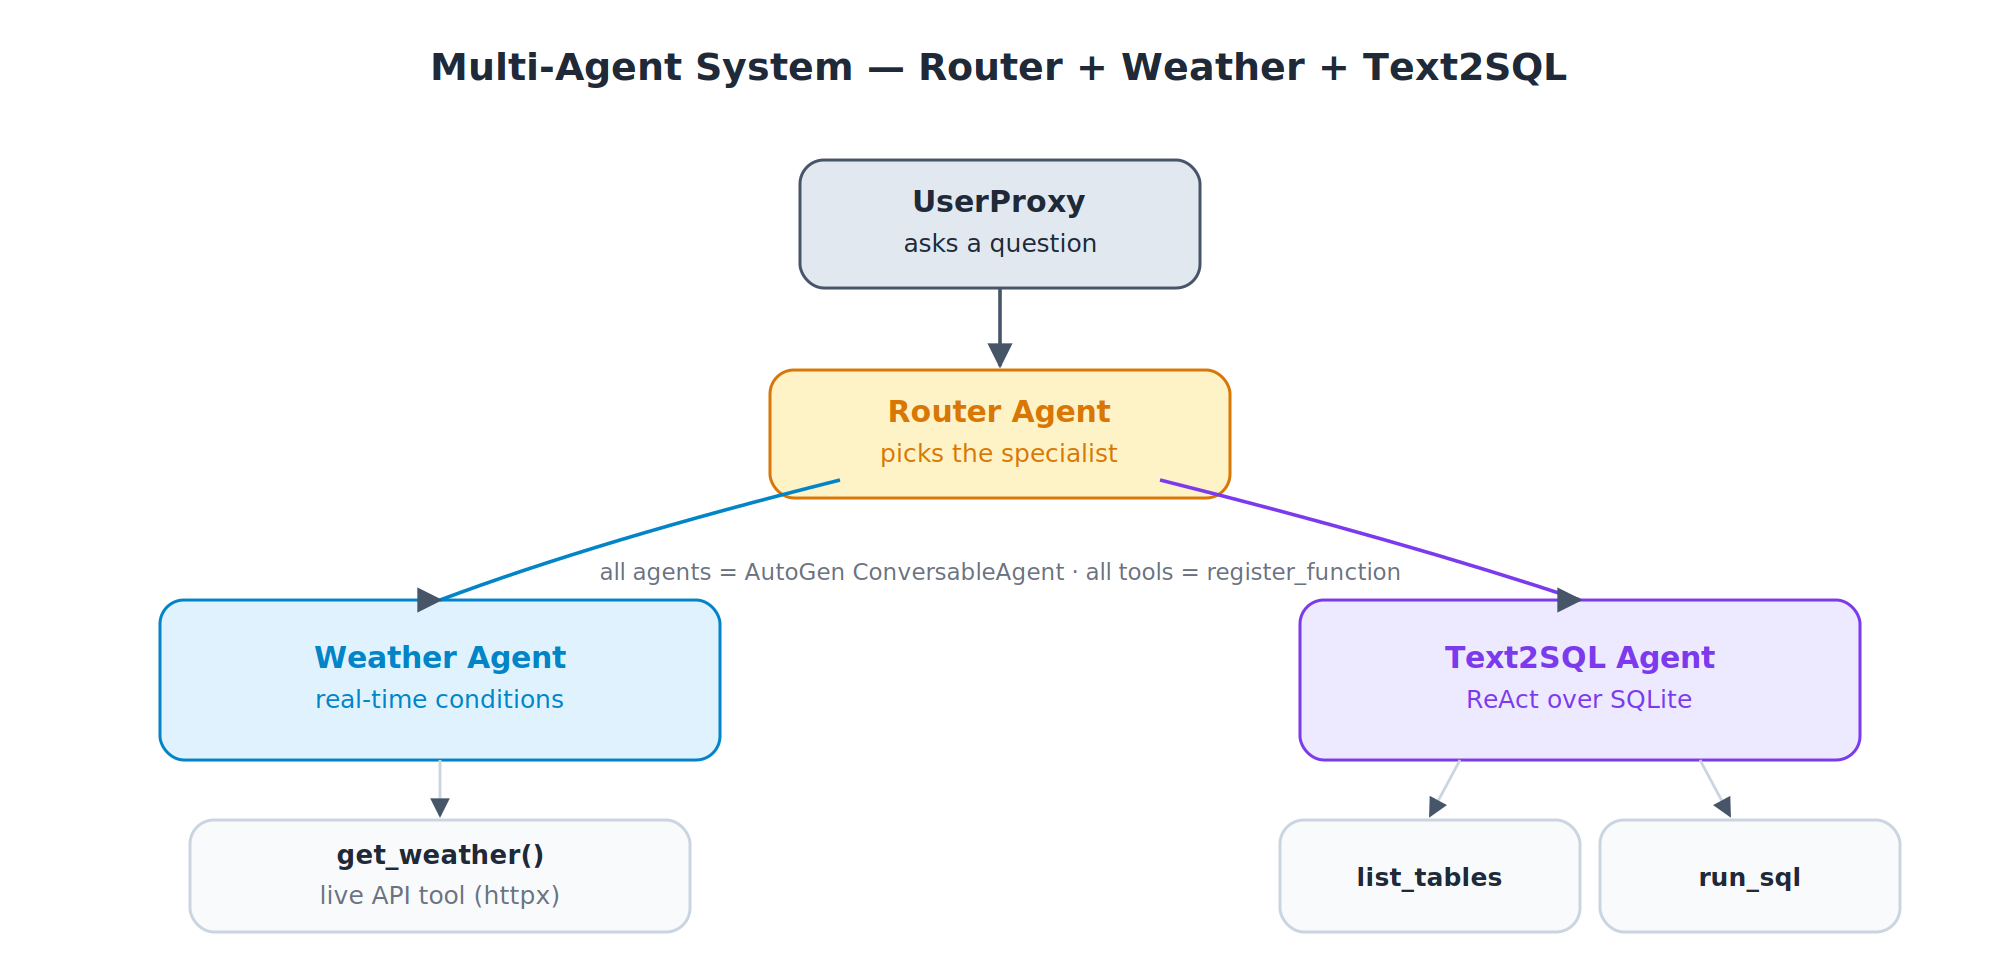

## The project layout

A small, conventional `uv` project. `uv` keeps an exact, reproducible
dependency set in `uv.lock`; `uv run` executes inside that environment
without you ever activating a venv by hand.

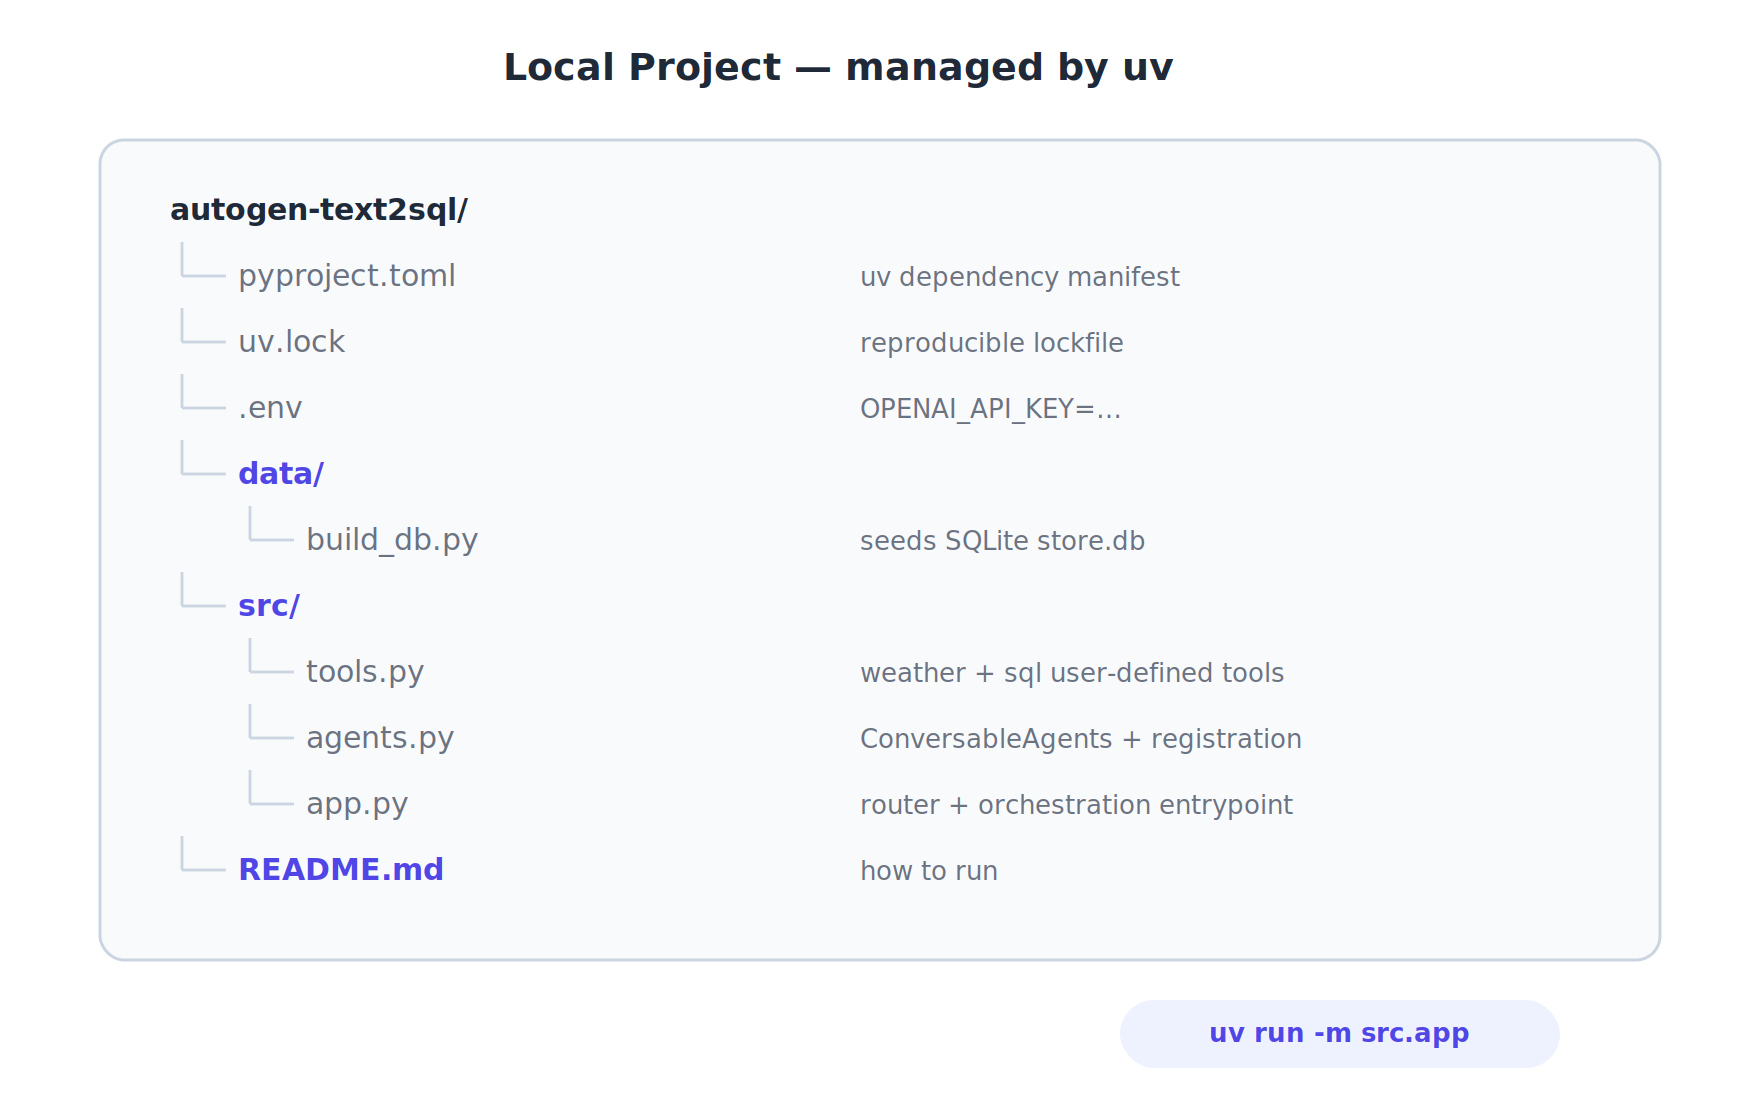

### Component map

| File | Role |
|---|---|
| `pyproject.toml` | Project + dependency manifest. `uv add` maintains it. |
| `.env.example` / `.env` | Where `OPENAI_API_KEY` lives. `.env` is git-ignored. |
| `src/config.py` | Loads `.env`, builds the one shared `llm_config`. |
| `src/build_db.py` | Creates and seeds the SQLite database (idempotent). |
| `src/tools.py` | The actual capabilities: `get_weather`, `list_tables`, `get_schema`, `run_sql`. |
| `src/agents.py` | Builds the weather + Text2SQL agents and a shared tool executor. |
| `src/app.py` | Keyword router + `answer()` entry point + CLI demo. |

A clean separation: tools are pure functions you can unit-test; agents
only wire them up; `app.py` is the only place that knows about user
input.

## Create the project with `uv`

The terminal flow from scratch:

```bash
# 1. scaffold a project (creates pyproject.toml + .venv on first run)
uv init autogen-text2sql
cd autogen-text2sql

# 2. add dependencies — resolved and written into uv.lock
uv add "ag2[openai]" httpx python-dotenv

# 3. put your key where python-dotenv will find it
cp .env.example .env        # then edit .env and paste your real key

# 4. build the demo database (idempotent)
uv run python -m src.build_db

# 5. run the multi-agent app
uv run python -m src.app
```

The cells below short-circuit all of that for the notebook: they
`%%writefile` every project file into `./autogen-text2sql/` next to this
notebook, so you end up with a real on-disk project without leaving
Jupyter.

### Create the directory structure

`%%writefile` does not create parent directories, so do that once first.

In [ ]:
from pathlib import Path

for d in [
    "autogen-text2sql",
    "autogen-text2sql/src",
    "autogen-text2sql/data",
]:
    Path(d).mkdir(parents=True, exist_ok=True)
print("Project skeleton ready.")

Project skeleton ready.


### `pyproject.toml`

The project manifest. `uv add` maintains the `dependencies` list; you
rarely edit it by hand. Python ≥ 3.10 is an AutoGen requirement.

In [ ]:
%%writefile autogen-text2sql/pyproject.toml
[project]
name = "autogen-text2sql"
version = "0.1.0"
description = "Multi-agent AutoGen demo: live weather + ReAct Text2SQL, run with uv"
requires-python = ">=3.10"
dependencies = [
    "ag2[openai]>=0.3",
    "httpx>=0.27",
    "python-dotenv>=1.0",
]

[build-system]
requires = ["hatchling"]
build-backend = "hatchling.build"

[tool.hatch.build.targets.wheel]
packages = ["src"]


Writing autogen-text2sql/pyproject.toml


### `.gitignore` and `.env.example`

Never commit `.env`. The example file documents which variables are
required.

In [ ]:
%%writefile autogen-text2sql/.gitignore
.venv/
__pycache__/
.env
data/store.db


Writing autogen-text2sql/.gitignore

In [ ]:
%%writefile autogen-text2sql/.env.example
# Copy to .env and fill in. .env is git-ignored.
OPENAI_API_KEY=sk-replace-me
# Optional: override the default model
OPENAI_MODEL=gpt-4o-mini


Writing autogen-text2sql/.env.example


### `src/config.py`

Loads `.env` and builds the one `llm_config` dict every agent shares.

In [ ]:
%%writefile autogen-text2sql/src/__init__.py
"""autogen-text2sql package."""


Writing autogen-text2sql/src/__init__.py


In [ ]:
%%writefile autogen-text2sql/src/config.py
"""Central configuration: load .env and expose the shared llm_config."""
import os

from dotenv import load_dotenv

load_dotenv()

OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY", "")
MODEL = os.environ.get("OPENAI_MODEL", "gpt-4o-mini")

# The classic AutoGen dict-style config. AutoGen reads OPENAI_API_KEY from
# the environment; we pass it explicitly so a missing key fails loudly.
llm_config = {
    "config_list": [
        {"model": MODEL, "api_key": OPENAI_API_KEY},
    ],
    "temperature": 0,
}


def require_key() -> None:
    """Fail early with a clear message if the key is absent."""
    if not OPENAI_API_KEY or OPENAI_API_KEY == "sk-replace-me":
        raise SystemExit(
            "OPENAI_API_KEY is not set. Copy .env.example to .env and "
            "paste your real key, then re-run with `uv run`."
        )


Writing autogen-text2sql/src/config.py


### `src/build_db.py` — the demo database

A tiny retail schema (`customers`, `products`, `orders`) seeded with a
handful of rows so the Text2SQL agent has something real to query.
Idempotent.

In [ ]:
%%writefile autogen-text2sql/src/build_db.py
"""Create and seed store.db — a tiny retail database for the demo."""
import sqlite3
from pathlib import Path

DB_PATH = Path(__file__).resolve().parent.parent / "data" / "store.db"

SCHEMA = """
DROP TABLE IF EXISTS orders;
DROP TABLE IF EXISTS products;
DROP TABLE IF EXISTS customers;

CREATE TABLE customers (
    id        INTEGER PRIMARY KEY,
    name      TEXT NOT NULL,
    city      TEXT NOT NULL,
    signup    TEXT NOT NULL          -- ISO date
);

CREATE TABLE products (
    id        INTEGER PRIMARY KEY,
    name      TEXT NOT NULL,
    category  TEXT NOT NULL,
    price     REAL NOT NULL
);

CREATE TABLE orders (
    id           INTEGER PRIMARY KEY,
    customer_id  INTEGER NOT NULL REFERENCES customers(id),
    product_id   INTEGER NOT NULL REFERENCES products(id),
    quantity     INTEGER NOT NULL,
    order_date   TEXT NOT NULL
);
"""

CUSTOMERS = [
    (1, "Asha Rao", "Hyderabad", "2024-01-12"),
    (2, "Liam Chen", "Singapore", "2024-02-03"),
    (3, "Maria Gomez", "Madrid", "2024-02-21"),
    (4, "Tom Becker", "Berlin", "2024-03-15"),
    (5, "Priya Nair", "Hyderabad", "2024-04-02"),
]

PRODUCTS = [
    (1, "Mechanical Keyboard", "Peripherals", 89.0),
    (2, "27-inch Monitor", "Displays", 219.0),
    (3, "USB-C Dock", "Peripherals", 129.0),
    (4, "Noise-cancelling Headphones", "Audio", 175.0),
    (5, "Webcam 1080p", "Peripherals", 59.0),
]

ORDERS = [
    (1, 1, 1, 2, "2024-04-05"),
    (2, 1, 3, 1, "2024-04-06"),
    (3, 2, 2, 1, "2024-04-09"),
    (4, 3, 4, 1, "2024-04-11"),
    (5, 4, 2, 2, "2024-04-15"),
    (6, 5, 5, 3, "2024-04-18"),
    (7, 1, 4, 1, "2024-04-20"),
    (8, 5, 1, 1, "2024-04-22"),
]


def main() -> None:
    DB_PATH.parent.mkdir(parents=True, exist_ok=True)
    conn = sqlite3.connect(DB_PATH)
    try:
        conn.executescript(SCHEMA)
        conn.executemany("INSERT INTO customers VALUES (?,?,?,?)", CUSTOMERS)
        conn.executemany("INSERT INTO products  VALUES (?,?,?,?)", PRODUCTS)
        conn.executemany("INSERT INTO orders    VALUES (?,?,?,?,?)", ORDERS)
        conn.commit()
    finally:
        conn.close()
    print(f"Seeded {DB_PATH} "
          f"({len(CUSTOMERS)} customers, {len(PRODUCTS)} products, "
          f"{len(ORDERS)} orders).")


if __name__ == "__main__":
    main()


Writing autogen-text2sql/src/build_db.py


Build it now — no LLM, no key required.

In [ ]:
!python autogen-text2sql/src/build_db.py

Seeded /tmp/nbtest/autogen-text2sql/data/store.db (5 customers, 5 products, 8 orders).


### `src/tools.py` — the AutoGen tools

Four plain functions, each fully type-annotated with `Annotated[...]` so
AutoGen can derive the JSON schema the model sees.

- **`get_weather(city)`** — geocodes the city and fetches *live* current
  conditions from Open-Meteo over `httpx`. No API key.
- **`list_tables()` / `get_schema(table)` / `run_sql(query)`** — the
  user-defined Text2SQL toolkit for Agent 2.

Three layers of safety live in the tool, not the prompt:

1. **textual guardrail** — `run_sql` refuses anything that is not a single
   `SELECT`;
2. **connection mode** — the database is opened with `?mode=ro`, so even
   a bypassed guardrail can't write;
3. **identifier validation** — `get_schema` checks the table name against
   the real table list before interpolating it into `PRAGMA`;
4. **row cap** — `run_sql` returns at most `MAX_ROWS` rows and flags
   truncation.

In [ ]:
%%writefile autogen-text2sql/src/tools.py
"""Tools exposed to the agents. Plain functions + type hints =
AutoGen-ready tool schemas."""
import sqlite3
from pathlib import Path
from typing import Annotated

import httpx

DB_PATH = Path(__file__).resolve().parent.parent / "data" / "store.db"

# Cap on rows returned by run_sql. The agent can always add LIMIT/WHERE to
# narrow further; this is just a backstop against runaway result sets.
MAX_ROWS = 50

# --------------------------------------------------------------------- #
# Weather agent's tool: a real, key-free live API (Open-Meteo).
# --------------------------------------------------------------------- #
def get_weather(
    city: Annotated[str, "City name, e.g. 'Hyderabad' or 'Berlin'."],
) -> Annotated[str, "A short human-readable current-weather summary."]:
    """Look up live current weather for a city via the Open-Meteo API."""
    with httpx.Client(timeout=15) as client:
        geo = client.get(
            "https://geocoding-api.open-meteo.com/v1/search",
            params={"name": city, "count": 1},
        ).json()
        if not geo.get("results"):
            return f"Could not find a location named {city!r}."
        loc = geo["results"][0]
        lat, lon = loc["latitude"], loc["longitude"]
        label = f"{loc['name']}, {loc.get('country', '')}".strip(", ")

        wx = client.get(
            "https://api.open-meteo.com/v1/forecast",
            params={"latitude": lat, "longitude": lon,
                    "current": "temperature_2m,wind_speed_10m,"
                               "relative_humidity_2m"},
        ).json()["current"]

    return (
        f"Current weather in {label}: "
        f"{wx['temperature_2m']}°C, "
        f"humidity {wx['relative_humidity_2m']}%, "
        f"wind {wx['wind_speed_10m']} km/h."
    )


# --------------------------------------------------------------------- #
# Text2SQL agent's user-defined tools (ReAct: list -> schema -> run).
# All query tools open the database in read-only mode.
# --------------------------------------------------------------------- #
def _connect_ro() -> sqlite3.Connection:
    """Open the database in read-only mode for query tools."""
    if not DB_PATH.exists():
        raise FileNotFoundError(
            f"{DB_PATH} not found. Run: uv run python -m src.build_db"
        )
    # SQLite URI with mode=ro guarantees no writes are possible even if the
    # SQL guardrail in run_sql is ever bypassed.
    return sqlite3.connect(f"file:{DB_PATH}?mode=ro", uri=True)


def _list_table_names(conn: sqlite3.Connection) -> list[str]:
    return [
        r[0]
        for r in conn.execute(
            "SELECT name FROM sqlite_master WHERE type='table' "
            "ORDER BY name"
        ).fetchall()
    ]


def list_tables() -> Annotated[str, "Comma-separated list of table names."]:
    """List the tables available in the database."""
    conn = _connect_ro()
    try:
        names = _list_table_names(conn)
    finally:
        conn.close()
    return ", ".join(names)


def get_schema(
    table: Annotated[str, "Exact table name to describe."],
) -> Annotated[str, "Column definitions: name TYPE per line."]:
    """Return the column names and types for one table.

    The table name is validated against the actual list of tables before it
    is interpolated into the PRAGMA call — never trust an LLM-supplied
    identifier blindly.
    """
    conn = _connect_ro()
    try:
        valid = _list_table_names(conn)
        if table not in valid:
            return (
                f"No such table: {table!r}. "
                f"Valid tables: {', '.join(valid)}."
            )
        cols = conn.execute(f"PRAGMA table_info({table})").fetchall()
    finally:
        conn.close()
    return "\n".join(f"{c[1]} {c[2]}" for c in cols)


def run_sql(
    query: Annotated[str, "A single read-only SELECT statement."],
) -> Annotated[str, "Query result rows, or an error string."]:
    """Execute one read-only SELECT and return the rows as text.

    Three layers of safety:
      1. textual guardrail: refuse anything that is not a single SELECT;
      2. connection mode: open the database with ?mode=ro so writes raise;
      3. row cap: return at most MAX_ROWS rows and flag truncation.
    """
    cleaned = query.strip().rstrip(";").strip()
    if ";" in cleaned:
        return "Refused: only a single statement is allowed."
    if not cleaned.lower().startswith("select"):
        return "Refused: only read-only SELECT queries are allowed."

    conn = _connect_ro()
    try:
        cur = conn.execute(cleaned)
        headers = [d[0] for d in cur.description]
        rows = cur.fetchmany(MAX_ROWS + 1)
    except sqlite3.Error as exc:
        return f"SQL error: {exc}"
    finally:
        conn.close()

    truncated = len(rows) > MAX_ROWS
    rows = rows[:MAX_ROWS]

    if not rows:
        return "(no rows)"
    out = [" | ".join(headers)]
    out += [" | ".join(str(v) for v in r) for r in rows]
    if truncated:
        out.append(
            f"(truncated to first {MAX_ROWS} rows — "
            "add LIMIT or WHERE to your query for the full set)"
        )
    return "\n".join(out)


Writing autogen-text2sql/src/tools.py


### Test the tools directly — *before* any agent touches them

Tools are deterministic code; test them as code, not by hoping the agent
gets it right. If the tools are broken, the agent is doomed; if they
pass, you've isolated the failure surface.

In [ ]:
import sys
sys.path.insert(0, "autogen-text2sql")
import importlib, src.tools
importlib.reload(src.tools)
from src.tools import list_tables, get_schema, run_sql

print("--- list_tables ---")
print(list_tables())

print("\n--- get_schema('orders') ---")
print(get_schema("orders"))

print("\n--- get_schema('users')  [invalid: validated, not interpolated] ---")
print(get_schema("users"))

print("\n--- run_sql: top-revenue product ---")
print(run_sql(
    "SELECT p.name, SUM(o.quantity*p.price) AS revenue "
    "FROM orders o JOIN products p ON o.product_id = p.id "
    "GROUP BY p.id ORDER BY revenue DESC LIMIT 1"
))

print("\n--- guardrail: DROP is refused (textual) ---")
print(run_sql("DROP TABLE orders"))

print("\n--- guardrail: multi-statement is refused (textual) ---")
print(run_sql("SELECT 1; SELECT 2"))

print("\n--- row cap: 50 rows max, truncation is flagged ---")
print(run_sql(
    "SELECT c.id, p.id FROM customers c, products p, orders o"
).rsplit("\n", 1)[-1])

--- list_tables ---
customers, orders, products

--- get_schema('orders') ---
id INTEGER
customer_id INTEGER
product_id INTEGER
quantity INTEGER
order_date TEXT

--- get_schema('users')  [invalid: validated, not interpolated] ---
No such table: 'users'. Valid tables: customers, orders, products.

--- run_sql: top-revenue product ---
name | revenue
27-inch Monitor | 657.0

--- guardrail: DROP is refused (textual) ---
Refused: only read-only SELECT queries are allowed.

--- guardrail: multi-statement is refused (textual) ---
Refused: only a single statement is allowed.

--- row cap: 50 rows max, truncation is flagged ---
(truncated to first 50 rows — add LIMIT or WHERE to your query for the full set)


### How the Text2SQL agent thinks: the ReAct loop

The Text2SQL agent is not given the schema up front. Following the
`react_text2sql` pattern, it *discovers* the database the way a careful
analyst would: list the tables, inspect only the relevant schema, draft a
`SELECT`, run it, read the rows, and answer. Each tool call is an
**Action**; each return value is an **Observation**; the model's
reasoning between them is the **Thought**. The loop ends when the agent
has enough to answer.

![image](https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/198/903/original/img7.png?1779712691)

### `src/agents.py` — building and wiring the agents

Each specialist is a caller `ConversableAgent` plus a shared non-LLM
`tool_executor` that actually runs the functions. The Text2SQL agent's
`system_message` *is* the ReAct instruction set — it tells the model to
list, inspect, then query, and to stop with a one-line answer prefixed
`FINAL:`.

In [ ]:
%%writefile autogen-text2sql/src/agents.py
"""Construct the weather agent, the ReAct Text2SQL agent, and a
shared tool executor."""
from autogen import ConversableAgent, register_function

from .config import llm_config
from .tools import get_schema, get_weather, list_tables, run_sql

TERMINATE = lambda m: m.get("content") is not None and "FINAL:" in m["content"]


def build_tool_executor() -> ConversableAgent:
    """A non-LLM agent that executes tool calls and stops on FINAL:."""
    return ConversableAgent(
        name="tool_executor",
        llm_config=False,
        human_input_mode="NEVER",
        is_termination_msg=TERMINATE,
        default_auto_reply="",
    )


def build_weather_agent() -> ConversableAgent:
    return ConversableAgent(
        name="weather_agent",
        system_message=(
            "You report current weather. Call get_weather(city) exactly "
            "once with the city from the user's question, then reply with "
            "one line starting with 'FINAL:' that states the conditions. "
            "Do not call any other tool."
        ),
        llm_config=llm_config,
        human_input_mode="NEVER",
    )


def build_text2sql_agent() -> ConversableAgent:
    return ConversableAgent(
        name="text2sql_agent",
        system_message=(
            "You answer questions about a SQLite database by reasoning step "
            "by step (ReAct). Follow this loop strictly:\n"
            "1. Call list_tables() to see what exists.\n"
            "2. Call get_schema(table) only for the tables you need.\n"
            "3. Write ONE read-only SELECT and call run_sql(query).\n"
            "4. Inspect the observation. If it answers the question, stop. "
            "Otherwise refine and call run_sql again.\n"
            "When you can answer, reply with a single line starting with "
            "'FINAL:' that gives the answer in plain English. Never invent "
            "table or column names — always verify with the tools first."
        ),
        llm_config=llm_config,
        human_input_mode="NEVER",
    )


def wire_tools(executor: ConversableAgent,
                weather_agent: ConversableAgent,
                text2sql_agent: ConversableAgent) -> None:
    """Register each tool to its caller + the shared executor."""
    register_function(
        get_weather, caller=weather_agent, executor=executor,
        name="get_weather",
        description="Get the live current weather for a city.",
    )
    for fn, desc in (
        (list_tables, "List the tables in the database."),
        (get_schema, "Get the columns and types of one table."),
        (run_sql, "Run one read-only SELECT and return the rows."),
    ):
        register_function(
            fn, caller=text2sql_agent, executor=executor,
            name=fn.__name__, description=desc,
        )


Writing autogen-text2sql/src/agents.py


### `src/app.py` — the router and end-to-end flow

A keyword router (kept deliberately simple) decides whether a question
is about weather or about the data, then runs that specialist's
caller↔executor chat.

![image](https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/198/904/original/img8.png?1779712718)

In [ ]:
%%writefile autogen-text2sql/src/app.py
"""Entry point: route each question to the weather or Text2SQL agent."""
from .agents import (
    build_text2sql_agent,
    build_tool_executor,
    build_weather_agent,
    wire_tools,
)
from .config import require_key

WEATHER_HINTS = ("weather", "temperature", "rain", "hot", "cold",
                 "forecast", "humid", "wind")


def route(question: str) -> str:
    """Return 'weather' or 'sql' based on simple keyword heuristics."""
    q = question.lower()
    return "weather" if any(h in q for h in WEATHER_HINTS) else "sql"


def answer(question: str) -> str:
    executor = build_tool_executor()
    weather_agent = build_weather_agent()
    text2sql_agent = build_text2sql_agent()
    wire_tools(executor, weather_agent, text2sql_agent)

    target = weather_agent if route(question) == "weather" else text2sql_agent
    chat = executor.initiate_chat(
        target, message=question, max_turns=8, silent=False
    )
    # The FINAL: line is the last substantive message.
    for msg in reversed(chat.chat_history):
        c = msg.get("content") or ""
        if "FINAL:" in c:
            return c[c.index("FINAL:"):].strip()
    return "(no FINAL answer produced)"


DEMO_QUESTIONS = [
    "What's the weather in Hyderabad right now?",
    "Which product has generated the most total revenue, and how much?",
]


def main() -> None:
    require_key()
    for q in DEMO_QUESTIONS:
        print("\n" + "=" * 70)
        print("Q:", q, "  ->  routed to:", route(q))
        print("=" * 70)
        print(answer(q))


if __name__ == "__main__":
    main()


Writing autogen-text2sql/src/app.py


### `README.md`

In [ ]:
%%writefile autogen-text2sql/README.md
# autogen-text2sql

A small **AutoGen** multi-agent demo, run entirely with **`uv`**.

- **Weather agent** — calls a live, key-free weather API (Open-Meteo)
  through an AutoGen tool.
- **Text2SQL agent** — answers questions over a local SQLite database using
  user-defined tools (`list_tables`, `get_schema`, `run_sql`) in a **ReAct**
  loop.
- **Router** — sends each question to the right specialist.

## Run it

```bash
uv add "ag2[openai]" httpx python-dotenv   # first time only
cp .env.example .env                       # then paste your OpenAI key
uv run python -m src.build_db              # create + seed store.db
uv run python -m src.app                   # ask the two demo questions
```

Ask your own question by editing `DEMO_QUESTIONS` in `src/app.py`, or import
`answer()` from it.

## Layout

```
autogen-text2sql/
├── pyproject.toml      # deps (uv add maintains this)
├── uv.lock             # exact, reproducible versions (uv writes this)
├── .env.example        # copy to .env, add your key
├── data/
│   └── store.db        # created by src/build_db.py
└── src/
    ├── config.py       # loads .env, builds the shared llm_config
    ├── build_db.py     # creates + seeds the SQLite database
    ├── tools.py        # get_weather + list_tables/get_schema/run_sql
    ├── agents.py       # builds + wires the agents
    └── app.py          # router + end-to-end entry point
```

Requires Python ≥ 3.10. The `ag2`, `autogen`, and `pyautogen` PyPI names all
install the same library; the import is `import autogen`.


Writing autogen-text2sql/README.md


## End-to-end run from the notebook

The full project is now on disk. The cell below imports it like any
other Python package, rebuilds the database (cheap), shows the router's
decisions for each demo question (no LLM needed), and runs the live
`answer()` end-to-end **only if** `OPENAI_API_KEY` is set.

In [ ]:
import importlib, os, sys
sys.path.insert(0, "autogen-text2sql")
for mod in ("src.build_db", "src.config", "src.tools", "src.agents", "src.app"):
    if mod in sys.modules:
        importlib.reload(sys.modules[mod])
from src.build_db import main as build_db
from src.app import answer, route

build_db()

questions = [
    "What's the weather in Hyderabad right now?",
    "Which product has generated the most total revenue, and how much?",
]

print("\n--- Router decisions (no LLM needed) ---")
for q in questions:
    print(f"  route({q!r}) -> {route(q)}")

if os.environ.get("OPENAI_API_KEY"):
    print("\n--- Live end-to-end runs ---")
    for q in questions:
        print(f"\nQ: {q}")
        print(answer(q))
else:
    print("\n(live answer() skipped — set OPENAI_API_KEY to run end-to-end)")

Seeded /tmp/nbtest/autogen-text2sql/data/store.db (5 customers, 5 products, 8 orders).

--- Router decisions (no LLM needed) ---
  route("What's the weather in Hyderabad right now?") -> weather
  route('Which product has generated the most total revenue, and how much?') -> sql

(live answer() skipped — set OPENAI_API_KEY to run end-to-end)


### Where the keyword router fails

The router is intentionally trivial: a fixed bag of weather-related
words. That breaks the moment a question mixes domains or borrows
weather vocabulary metaphorically.

In [ ]:
from src.app import route

failures = [
    "How windy were sales in April?",                        # mis-routed to weather
    "Compare Hyderabad customers and the current Hyderabad weather.",
    "Will it be a good day for outdoor delivery in Berlin?",
]
for q in failures:
    print(f"  route({q!r}) -> {route(q)}")

  route('How windy were sales in April?') -> weather
  route('Compare Hyderabad customers and the current Hyderabad weather.') -> weather
  route('Will it be a good day for outdoor delivery in Berlin?') -> sql


**What this tells you.** A keyword router is fine for a teaching
demo but brittle in production. Upgrades:

- a small **LLM router** that returns a structured `{intent, confidence}`;
- a **classifier** trained on a few hundred labelled questions;
- a **group chat** (Part 1's `GroupChatManager` pattern) where the
  manager picks the next speaker from the full conversation;
- a **clarification path** when confidence is below a threshold.

## Running it

With a key in `.env`:

```bash
cd autogen-text2sql
uv add "ag2[openai]" httpx python-dotenv   # first time only
cp .env.example .env                       # then paste your real key
uv run python -m src.build_db              # already done above
uv run python -m src.app
```

You will see, for the first question, the weather agent make a single
`get_weather` tool call and emit a `FINAL:` line with live conditions;
for the second, the Text2SQL agent walk the ReAct loop —
`list_tables` → `get_schema(orders)` / `get_schema(products)` → a
`SELECT` joining `orders` and `products` with `SUM(quantity*price)` → a
`FINAL:` answer naming the top-revenue product.

## Troubleshooting

**`ModuleNotFoundError: No module named 'autogen'`** — install:
`%pip install -q "ag2[openai]"` (or `uv add "ag2[openai]"`).

**`OPENAI_API_KEY detected: False`** — set the env var before launching
Jupyter, or temporarily in a cell:
`os.environ["OPENAI_API_KEY"] = "sk-..."`. Don't commit notebooks with
keys inlined.

**`FileNotFoundError: autogen-text2sql/...`** — run the Part 2 cells
*in order*; each `%%writefile` cell creates one file.

**`No such file or directory: '.../data/store.db'`** — run the
`!python autogen-text2sql/src/build_db.py` cell.

**Tool never gets called.** Verify (a) the function was registered with
both `caller=` and `executor=`, (b) every argument uses
`Annotated[type, "description"]`, (c) the caller's `system_message`
instructs *when* to use the tool.

**Text2SQL agent invents column names.** The `system_message` already
requires `get_schema(table)` before `run_sql`. If it skips, tighten the
instruction and confirm `temperature: 0` in `llm_config`.

**Conversations don't stop.** Add an `is_termination_msg` predicate and
a phrase like `TERMINATE` or `FINAL:` to the relevant `system_message`.
`max_turns` is the blunt backup; the semantic predicate is the real stop.

## Minimum successful run

You're done with Part 2 when you can run these four checks in order and
see the expected output:

1. **`list_tables()`** → `customers, orders, products`
2. **`run_sql("SELECT p.name, SUM(o.quantity*p.price) AS rev FROM orders o JOIN products p ON o.product_id=p.id GROUP BY p.id ORDER BY rev DESC LIMIT 1")`** → `27-inch Monitor | 657.0`
3. **`answer("Which product has generated the most total revenue, and how much?")`** → a `FINAL:` line naming *27-inch Monitor* and *657*.
4. **`answer("What's the weather in Hyderabad right now?")`** → a `FINAL:` line with live temperature, humidity, and wind for Hyderabad.

Checks 1–2 are deterministic and need no API key. Checks 3–4 need a
valid `OPENAI_API_KEY`.

## Where to take it next

- **Smarter routing.** Replace the keyword `route()` with a tiny
  classifier agent or fold both specialists into a `GroupChat`.
- **More tools.** Add a `describe_all_schemas()` tool to cut the first
  ReAct round, or a charting tool that writes a PNG.
- **Safety.** Enforce a row `LIMIT`, add per-query timeouts.
- **Swap the model.** Only `src/config.py` references the model name;
  change `OPENAI_MODEL` in `.env`.

### Recap

Part 1 covered the whole AutoGen surface as small standalone examples:
`ConversableAgent`, two-agent conversations, termination, sequential
carry-over, reflection, nested review panels, tools via
`register_function`, code execution, and managed group chats. Part 2
turned the tool and routing patterns into a real, `uv`-managed project
where one agent does a live weather lookup and another answers questions
over a database with a safe ReAct SQL loop — every piece of it AutoGen.